# Long-range electrostatic interaction
## cluster_combined

In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as pltx
import matplotlib.pyplot as plt
import glob
%matplotlib inline

In [2]:
#cutoff for electrostat contact
contact_dist = 10
#making empty lists to put contact files in
nosalt_binding_sims = []
salt_binding_sims = []

In [3]:
#loading in all electrostat files from ArkA12 binding and binding with salt sims
nosalt_binding_sims = glob.glob('/data/rcarrock/ArkA_binding_cont/analysis_all/electrostat/*.dat')
salt_binding_sims = glob.glob('/data/mcohen3/SH3/analysis/electrostat/dat/*.dat')

#loading in status file so can define unbound, bound, and encounter within the ArkA12 binding sims
ArkA12_status = pd.read_csv("/data/rcarrock/ArkA_binding_cont/analysis_all/ArkA12_status.csv")
ArkA12_status_salt = pd.read_csv('/data/jcardoso/binding_figures_800ArkA12/ArkA12/pair_wise_distances/binding/salt/status_files/ArkA12_binding_salt_status.csv')

# Binding simulations

# ArkA12 binding simulations

In [4]:
#define number of independent sims for bound sims
num_binding_sims = 50
#make dataframes for the fraction of electrostats and for the sem of that
electrostat_frac = pd.DataFrame(columns=['binding nosalt', 'unbound nosalt', 'bound nosalt', 'encounter nosalt', 'binding 800 NaCl', 'unbound 800 NaCl', 'bound 800 NaCl','encounter 800 NaCl'])
electrostat_frac_sem = pd.DataFrame(columns=['binding nosalt', 'unbound nosalt', 'bound nosalt', 'encounter nosalt', 'binding 800 NaCl', 'unbound 800 NaCl', 'bound 800 NaCl','encounter 800 NaCl'])
#make dataframe for total electrostat frac for each independent bound sim 
total_electrostat_frac_binding = pd.DataFrame(0, columns=['binding nosalt', 'unbound nosalt', 'bound nosalt', 'encounter nosalt', 'binding 800 NaCl', 'unbound 800 NaCl', 'bound 800 NaCl','encounter 800 NaCl'], index = range(0,num_binding_sims))

for file_name in nosalt_binding_sims:
    df_binding = pd.read_table(file_name, sep = '\s+')
    df_binding = df_binding.drop(['#Frame'], axis=1)
    df_binding.columns = ['fraction']
    df_binding['status'] = ArkA12_status['status']
    
#calculate the mean for each contact over all independent sims
    #less than contact_dist
    less_than_10 = df_binding['fraction'] < contact_dist 
    electrostat_frac.loc[file_name.split('/')[-1],
                     'binding nosalt'] = np.mean(less_than_10)
    
    #less than contact_dist and unbound
    less_than_10_unbound = ((df_binding['fraction'] < contact_dist) 
                            & (df_binding['status'] == 'unbound'))
    len_sim_unbound = (df_binding['status'] == 'unbound').sum()
    num_contacts_unbound = less_than_10_unbound.sum(axis = 0)
    electrostat_frac.loc[file_name.split('/')[-1],
                     'unbound nosalt'] = (num_contacts_unbound/len_sim_unbound)
    
    #less than contact_dist and encounter
    less_than_10_encounter = ((df_binding['fraction'] < contact_dist) 
                            & (df_binding['status'] != 'unbound nosalt') & (df_binding['status'] != 'Bound'))
    len_sim_encounter = ((df_binding['status'] != 'unbound nosalt') & (df_binding['status'] != 'Bound')).sum()
    num_contacts_encounter = less_than_10_encounter.sum(axis = 0)
    electrostat_frac.loc[file_name.split('/')[-1],
                     'encounter nosalt'] = (num_contacts_encounter/len_sim_encounter)
    
     #less than contact_dist and bound
    less_than_10_bound = ((df_binding['fraction'] < contact_dist) 
                            & (df_binding['status'] == 'Bound'))
    len_sim_bound = (df_binding['status'] == 'Bound').sum()
    num_contacts_bound = less_than_10_bound.sum(axis = 0)
    electrostat_frac.loc[file_name.split('/')[-1],
                     'bound nosalt'] = (num_contacts_bound/len_sim_bound)

#calculate standard error of the mean
    num_binding_snapshots = int(len(df_binding)/num_binding_sims)

    frac_by_sim = pd.DataFrame(columns=['binding nosalt', 'unbound nosalt', 'bound nosalt', 'encounter nosalt'])
    
    #go through each of the independent binding simulations
    for sim in range(0,num_binding_sims):
        #less than contact_dist
        frac_by_sim.loc[sim,'binding nosalt'] = np.mean(df_binding[sim*num_binding_snapshots:
                (sim+1)*num_binding_snapshots]['fraction']
                        < contact_dist)
        total_electrostat_frac_binding.loc[sim,'binding nosalt'] += np.mean(df_binding[sim*num_binding_snapshots:
                (sim+1)*num_binding_snapshots]['fraction']
                        < contact_dist)

        #less than contact_dist and unbound
        df_sim = df_binding[sim*num_binding_snapshots:(sim+1)*num_binding_snapshots] 
        less_than_10_unbound_sim = ((df_sim['fraction'] < contact_dist) 
                            & (df_sim['status'] == 'unbound'))
        len_sim_unbound_sim = (df_sim['status'] == 'unbound').sum()
        num_contacts_unbound_sim = less_than_10_unbound_sim.sum(axis = 0)
        frac_by_sim.loc[sim,'unbound nosalt'] = (num_contacts_unbound_sim/len_sim_unbound_sim)
        total_electrostat_frac_binding.loc[sim,'unbound nosalt'] += (num_contacts_unbound_sim/len_sim_unbound_sim)
        
        #less than contact_dist and encounter 
        less_than_10_encounter_sim = ((df_sim['fraction'] < contact_dist) 
                            & (df_sim['status'] != 'unbound nosalt') & (df_sim['status'] != 'Bound'))
        len_sim_encounter_sim = ((df_sim['status'] != 'unbound nosalt') & (df_sim['status'] != 'Bound')).sum()
        num_contacts_encounter_sim = less_than_10_encounter_sim.sum(axis = 0)
        frac_by_sim.loc[sim,'encounter nosalt'] = (num_contacts_encounter_sim/len_sim_encounter_sim)
        total_electrostat_frac_binding.loc[sim,'encounter nosalt'] += (num_contacts_encounter_sim/len_sim_encounter_sim)
        
        #less than contact_dist and bound 
        less_than_10_bound_sim = ((df_sim['fraction'] < contact_dist) 
                            & (df_sim['status'] == 'Bound'))
        len_sim_bound_sim = (df_sim['status'] == 'Bound').sum()
        num_contacts_bound_sim = less_than_10_bound_sim.sum(axis = 0)
        frac_by_sim.loc[sim,'bound nosalt'] = (num_contacts_bound_sim/len_sim_bound_sim)
        total_electrostat_frac_binding.loc[sim,'bound nosalt'] += (num_contacts_bound_sim/len_sim_bound_sim)
        
    electrostat_frac_sem.loc[file_name.split('/')[-1],'binding nosalt'] = frac_by_sim.sem()['binding nosalt']
    electrostat_frac_sem.loc[file_name.split('/')[-1],'unbound nosalt'] = frac_by_sim.sem()['unbound nosalt']
    electrostat_frac_sem.loc[file_name.split('/')[-1],'encounter nosalt'] = frac_by_sim.sem()['encounter nosalt']
    electrostat_frac_sem.loc[file_name.split('/')[-1],'bound nosalt'] = frac_by_sim.sem()['bound nosalt']
electrostat_frac

/tmp/ipykernel_3719857/1808566191.py:56: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.95151' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  total_electrostat_frac_binding.loc[sim,'binding nosalt'] += np.mean(df_binding[sim*num_binding_snapshots:
/tmp/ipykernel_3719857/1808566191.py:67: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.0015037593984962407' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  total_electrostat_frac_binding.loc[sim,'unbound nosalt'] += (num_contacts_unbound_sim/len_sim_unbound_sim)
/tmp/ipykernel_3719857/1808566191.py:75: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.9493484114162628' has dtype incompatible with int64, please expli

,binding nosalt,unbound nosalt,bound nosalt,encounter nosalt,binding 800 NaCl,unbound 800 NaCl,bound 800 NaCl,encounter 800 NaCl
D9_K60.dat,0.339098,0.056718,0.85614,0.249023,NaN,NaN,NaN,NaN
D11_K60.dat,0.280488,0.090569,0.747985,0.199044,NaN,NaN,NaN,NaN
D15_K60.dat,0.057586,0.092764,0.000015,0.067616,NaN,NaN,NaN,NaN
D24_K60.dat,0.014531,0.020884,0.009501,0.015408,NaN,NaN,NaN,NaN
D33_K60.dat,0.079349,0.040016,0.000004,0.093172,NaN,NaN,NaN,NaN
D34_K60.dat,0.062101,0.03764,0.000007,0.072918,NaN,NaN,NaN,NaN
D35_K60.dat,0.076018,0.03821,0.000559,0.089163,NaN,NaN,NaN,NaN
D44_K60.dat,0.011949,0.073355,0.0,0.014031,NaN,NaN,NaN,NaN
E7_K60.dat,0.184355,0.03236,0.112132,0.196937,NaN,NaN,NaN,NaN
E14_K60.dat,0.15444,0.092831,0.000154,0.181319,NaN,NaN,NaN,NaN


In [5]:
electrostat_frac_sem

,binding nosalt,unbound nosalt,bound nosalt,encounter nosalt,binding 800 NaCl,unbound 800 NaCl,bound 800 NaCl,encounter 800 NaCl
D9_K60.dat,0.049496,0.015629,0.071211,0.041382,NaN,NaN,NaN,NaN
D11_K60.dat,0.044087,0.02132,0.084577,0.033178,NaN,NaN,NaN,NaN
D15_K60.dat,0.014462,0.017804,0.000517,0.015118,NaN,NaN,NaN,NaN
D24_K60.dat,0.002439,0.006088,0.014554,0.005674,NaN,NaN,NaN,NaN
D33_K60.dat,0.01872,0.009604,0.000141,0.018561,NaN,NaN,NaN,NaN
D34_K60.dat,0.014357,0.007822,0.000235,0.014249,NaN,NaN,NaN,NaN
D35_K60.dat,0.016913,0.006923,0.033404,0.016986,NaN,NaN,NaN,NaN
D44_K60.dat,0.003195,0.010233,0.0,0.004864,NaN,NaN,NaN,NaN
E7_K60.dat,0.039167,0.0106,0.07334,0.039079,NaN,NaN,NaN,NaN
E14_K60.dat,0.031614,0.014463,0.018585,0.031391,NaN,NaN,NaN,NaN


In [6]:
electrostat_frac
electrostat_frac["binding nosalt"].mean()

0.11435648444444438

In [7]:
electrostat_frac
electrostat_frac["binding nosalt"].sem()

0.014681894133035977

In [8]:
electrostat_frac
electrostat_frac["unbound nosalt"].mean()

0.04522837715200258

In [9]:
electrostat_frac
electrostat_frac["bound nosalt"].mean()

0.13802692309132505

In [10]:
electrostat_frac
electrostat_frac["bound nosalt"].sem()

0.03892670483413795

In [11]:
electrostat_frac
electrostat_frac["bound nosalt"].sem()

0.03892670483413795

In [12]:
electrostat_frac
electrostat_frac["encounter nosalt"].mean()

0.11023281100471446

In [13]:
electrostat_frac
electrostat_frac["encounter nosalt"].sem()

0.012357941273012776

# Binding with salt 

In [14]:
#define number of independent sims for binding sims
num_binding_sims = 50
#make dataframe for total electrostat frac for each independent binding sim
total_electrostat_frac_binding_salt = pd.DataFrame(0, columns=['binding nosalt', 'unbound nosalt', 'bound nosalt', 'encounter nosalt', 'binding 800 NaCl', 'unbound 800 NaCl', 'bound 800 NaCl','encounter 800 NaCl'], index = range(0,num_binding_sims))

for file_name in salt_binding_sims:
    df_binding = pd.read_table(file_name, sep = '\s+')
    df_binding = df_binding.drop(['#Frame'], axis=1)
    df_binding.columns = ['fraction']
    df_binding['status'] = ArkA12_status_salt['status']
    
#calculate the mean for each contact over all independent sims
    #less than contact_dist
    less_than_10 = df_binding['fraction'] < contact_dist 
    electrostat_frac.loc[file_name.split('/')[-1],
                     'binding 800 NaCl'] = np.mean(less_than_10)
    
    #less than contact_dist and unbound
    less_than_10_unbound = ((df_binding['fraction'] < contact_dist) 
                            & (df_binding['status'] == 'unbound'))
    len_sim_unbound = (df_binding['status'] == 'unbound').sum()
    num_contacts_unbound = less_than_10_unbound.sum(axis = 0)
    electrostat_frac.loc[file_name.split('/')[-1],
                     'unbound 800 NaCl'] = (num_contacts_unbound/len_sim_unbound)
    
    #less than contact_dist and encounter
    less_than_10_encounter = ((df_binding['fraction'] < contact_dist) 
                            & (df_binding['status'] != 'unbound nosalt') & (df_binding['status'] != 'Bound'))
    len_sim_encounter = ((df_binding['status'] != 'unbound nosalt') & (df_binding['status'] != 'Bound')).sum()
    num_contacts_encounter = less_than_10_encounter.sum(axis = 0)
    electrostat_frac.loc[file_name.split('/')[-1],
                     'encounter 800 NaCl'] = (num_contacts_encounter/len_sim_encounter)
    
     #less than contact_dist and bound
    less_than_10_bound = ((df_binding['fraction'] < contact_dist) 
                            & (df_binding['status'] == 'Bound'))
    len_sim_bound = (df_binding['status'] == 'Bound').sum()
    num_contacts_bound = less_than_10_bound.sum(axis = 0)
    electrostat_frac.loc[file_name.split('/')[-1],
                     'bound 800 NaCl'] = (num_contacts_bound/len_sim_bound)

#calculate standard deviation
    num_binding_snapshots = int(len(df_binding)/num_binding_sims)

    frac_by_sim = pd.DataFrame(columns=['binding nosalt', 'unbound nosalt', 'bound nosalt', 'encounter nosalt'])
    
    #go through each of the independent binding simulations
    for sim in range(0,num_binding_sims):
        #less than contact_dist
        frac_by_sim.loc[sim,'binding nosalt'] = np.mean(df_binding[sim*num_binding_snapshots:
                (sim+1)*num_binding_snapshots]['fraction']
                        < contact_dist)
        total_electrostat_frac_binding_salt.loc[sim,'binding nosalt'] += np.mean(df_binding[sim*num_binding_snapshots:
                (sim+1)*num_binding_snapshots]['fraction']
                        < contact_dist)

        #less than contact_dist and unbound
        df_sim = df_binding[sim*num_binding_snapshots:(sim+1)*num_binding_snapshots] 
        less_than_10_unbound_sim = ((df_sim['fraction'] < contact_dist) 
                            & (df_sim['status'] == 'unbound'))
        len_sim_unbound_sim = (df_sim['status'] == 'unbound').sum()
        num_contacts_unbound_sim = less_than_10_unbound_sim.sum(axis = 0)
        frac_by_sim.loc[sim,'unbound nosalt'] = (num_contacts_unbound_sim/len_sim_unbound_sim)
        total_electrostat_frac_binding_salt.loc[sim,'unbound nosalt'] += (num_contacts_unbound_sim/len_sim_unbound_sim)
        
        #less than contact_dist and encounter 
        less_than_10_encounter_sim = ((df_sim['fraction'] < contact_dist) 
                            & (df_sim['status'] != 'unbound nosalt') & (df_sim['status'] != 'Bound'))
        len_sim_encounter_sim = ((df_sim['status'] != 'unbound nosalt') & (df_sim['status'] != 'Bound')).sum()
        num_contacts_encounter_sim = less_than_10_encounter_sim.sum(axis = 0)
        frac_by_sim.loc[sim,'encounter nosalt'] = (num_contacts_encounter_sim/len_sim_encounter_sim)
        total_electrostat_frac_binding_salt.loc[sim,'encounter nosalt'] += (num_contacts_encounter_sim/len_sim_encounter_sim)
        
        #less than contact_dist and bound 
        less_than_10_bound_sim = ((df_sim['fraction'] < contact_dist) 
                            & (df_sim['status'] == 'Bound'))
        len_sim_bound_sim = (df_sim['status'] == 'Bound').sum()
        num_contacts_bound_sim = less_than_10_bound_sim.sum(axis = 0)
        frac_by_sim.loc[sim,'bound nosalt'] = (num_contacts_bound_sim/len_sim_bound_sim)
        total_electrostat_frac_binding_salt.loc[sim,'bound nosalt'] += (num_contacts_bound_sim/len_sim_bound_sim)
        
    electrostat_frac_sem.loc[file_name.split('/')[-1],'binding 800 NaCl'] = frac_by_sim.sem()['binding nosalt']
    electrostat_frac_sem.loc[file_name.split('/')[-1],'unbound 800 NaCl'] = frac_by_sim.sem()['unbound nosalt']
    electrostat_frac_sem.loc[file_name.split('/')[-1],'encounter 800 NaCl'] = frac_by_sim.sem()['encounter nosalt']
    electrostat_frac_sem.loc[file_name.split('/')[-1],'bound 800 NaCl'] = frac_by_sim.sem()['bound nosalt']
electrostat_frac

/tmp/ipykernel_3719857/17285590.py:53: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.52156' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  total_electrostat_frac_binding_salt.loc[sim,'binding nosalt'] += np.mean(df_binding[sim*num_binding_snapshots:
/tmp/ipykernel_3719857/17285590.py:72: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.0954792935329046' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  total_electrostat_frac_binding_salt.loc[sim,'encounter nosalt'] += (num_contacts_encounter_sim/len_sim_encounter_sim)
/tmp/ipykernel_3719857/17285590.py:80: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.9965318163554465' has dtype incompatible with int64, pleas

,binding nosalt,unbound nosalt,bound nosalt,encounter nosalt,binding 800 NaCl,unbound 800 NaCl,bound 800 NaCl,encounter 800 NaCl
D9_K60.dat,0.339098,0.056718,0.85614,0.249023,0.147467,0.009437,0.883622,0.054653
D11_K60.dat,0.280488,0.090569,0.747985,0.199044,0.155908,0.014606,0.845742,0.068935
D15_K60.dat,0.057586,0.092764,0.000015,0.067616,0.046612,0.016641,0.000014,0.052487
D24_K60.dat,0.014531,0.020884,0.009501,0.015408,0.00415,0.003995,0.001892,0.004434
D33_K60.dat,0.079349,0.040016,0.000004,0.093172,0.067085,0.021588,0.0,0.075543
D34_K60.dat,0.062101,0.03764,0.000007,0.072918,0.047313,0.016877,0.000268,0.053244
D35_K60.dat,0.076018,0.03821,0.000559,0.089163,0.065597,0.02008,0.001486,0.07368
D44_K60.dat,0.011949,0.073355,0.0,0.014031,0.004676,0.01284,0.0,0.005266
E7_K60.dat,0.184355,0.03236,0.112132,0.196937,0.040292,0.006154,0.053173,0.038668
E14_K60.dat,0.15444,0.092831,0.000154,0.181319,0.232676,0.032204,0.000191,0.261988


In [15]:
electrostat_frac
electrostat_frac["binding 800 NaCl"].mean()

0.061734408888888856

In [16]:
electrostat_frac
electrostat_frac["binding 800 NaCl"].sem()

0.009177843738407429

In [17]:
electrostat_frac
electrostat_frac["unbound 800 NaCl"].mean()

0.012110598688832892

In [18]:
electrostat_frac
electrostat_frac["bound 800 NaCl"].mean()

0.12612845314970123

In [19]:
electrostat_frac
electrostat_frac["bound 800 NaCl"].sem()

0.03957010882279814

In [20]:
electrostat_frac
electrostat_frac["encounter 800 NaCl"].mean()

0.05361565890710511

In [21]:
electrostat_frac
electrostat_frac["encounter 800 NaCl"].sem()

0.00840032749907787

In [22]:
#calcs amount of contacts occuring on average at any given time
(electrostat_frac.mean())*len(electrostat_frac)

binding nosalt        5.146042
unbound nosalt        2.035277
bound nosalt          6.211212
encounter nosalt      4.960476
binding 800 NaCl      2.778048
unbound 800 NaCl      0.544977
bound 800 NaCl         5.67578
encounter 800 NaCl    2.412705
dtype: object

In [23]:
#calcs amount of contacts occuring on average at any given time
(electrostat_frac.sem())*len(electrostat_frac)

binding nosalt        0.660685
unbound nosalt        0.168535
bound nosalt          1.751702
encounter nosalt      0.556107
binding 800 NaCl      0.413003
unbound 800 NaCl      0.047166
bound 800 NaCl        1.780655
encounter 800 NaCl    0.378015
dtype: object

In [24]:
# ArkA12 binding_salt effect of NaCl (JUST LONG)
ArkA12_avg_hb_values = np.concatenate([(electrostat_frac["encounter nosalt"]*len(electrostat_frac)),
                                           (electrostat_frac["encounter 800 NaCl"]*len(electrostat_frac))])
#calculate the real difference, no salt minus salt
diff_ArkA12_long = ((electrostat_frac["encounter nosalt"].mean()*len(electrostat_frac)))\
        - ((electrostat_frac["encounter 800 NaCl"].mean()*len(electrostat_frac)))\

print("ArkA12 binding_salt 800 mM NaCl vs no-salt difference = " , diff_ArkA12_long)

#sample 10000 times and calculate differences
numsample = 10000
diff_ArkA12_samples = [0]*numsample
diff_ArkA12_samples_larger = [0]*numsample
for sample in range(0,len(diff_ArkA12_samples)):
    random_groups = np.random.permutation(ArkA12_avg_hb_values)
    diff_ArkA12_samples[sample] = (np.mean(random_groups[0:num_binding_sims]) 
             - np.mean(random_groups[num_binding_sims:num_binding_sims 
                                                + num_binding_sims]))
    if diff_ArkA12_samples[sample] >= diff_ArkA12_long:
        diff_ArkA12_samples_larger[sample] = 1

#calculate p-value
pval_diff_ArkA12 = (1 + np.sum(diff_ArkA12_samples_larger))/(numsample + 1)
print("p-value = " , pval_diff_ArkA12)

ArkA12 binding_salt 800 mM NaCl vs no-salt difference =  2.5477718443924213
p-value =  9.999000099990002e-05


In [25]:
electrostat_frac.to_csv('ArkA12_EC_long_range_EI_fracs.csv', columns=['encounter nosalt','encounter 800 NaCl'],index=False)

In [26]:
print((electrostat_frac["encounter nosalt"].mean()*len(electrostat_frac)))

4.960476495212151


In [27]:
#cutoff for important contacts b/c don't need ones w/o important role 
frac_cutoff = 0.1 
common_contacts = electrostat_frac > frac_cutoff

In [28]:
#making it so only those that meet cutoff show
electrostat_frac['important'] = common_contacts.any(axis = 1)
electrostat_frac_subset = electrostat_frac[electrostat_frac['important']]

#ditto but for sem
electrostat_frac_sem['important'] = common_contacts.any(axis = 1)
electrostat_frac_sem_subset = electrostat_frac_sem[electrostat_frac_sem['important']]

In [29]:
#checking new length... went from 45 to 25 contacts
len(electrostat_frac_sem_subset)

24

In [30]:
# total_electrostat_frac_binding

In [31]:
electrostat_frac_subset

,binding nosalt,unbound nosalt,bound nosalt,encounter nosalt,binding 800 NaCl,unbound 800 NaCl,bound 800 NaCl,encounter 800 NaCl,important
D9_K60.dat,0.339098,0.056718,0.85614,0.249023,0.147467,0.009437,0.883622,0.054653,True
D11_K60.dat,0.280488,0.090569,0.747985,0.199044,0.155908,0.014606,0.845742,0.068935,True
E7_K60.dat,0.184355,0.03236,0.112132,0.196937,0.040292,0.006154,0.053173,0.038668,True
E14_K60.dat,0.15444,0.092831,0.000154,0.181319,0.232676,0.032204,0.000191,0.261988,True
E17_K60.dat,0.192556,0.089614,0.000898,0.225945,0.251231,0.032451,0.001918,0.282664,True
E22_K60.dat,0.310131,0.049753,0.71415,0.239746,0.109051,0.00773,0.584032,0.049166,True
D9_K66.dat,0.170998,0.060093,0.004303,0.200039,0.050184,0.012434,0.000138,0.056494,True
D11_K66.dat,0.259996,0.064049,0.105541,0.286903,0.065479,0.008899,0.114577,0.059289,True
D15_K66.dat,0.167255,0.07688,0.466758,0.115078,0.122623,0.018753,0.348456,0.09415,True
D33_K66.dat,0.142327,0.03019,0.086882,0.151986,0.069686,0.0047,0.041758,0.073207,True


In [32]:
len(electrostat_frac[electrostat_frac['important']])

24

In [33]:
electrostat_frac[electrostat_frac['important']]

,binding nosalt,unbound nosalt,bound nosalt,encounter nosalt,binding 800 NaCl,unbound 800 NaCl,bound 800 NaCl,encounter 800 NaCl,important
D9_K60.dat,0.339098,0.056718,0.85614,0.249023,0.147467,0.009437,0.883622,0.054653,True
D11_K60.dat,0.280488,0.090569,0.747985,0.199044,0.155908,0.014606,0.845742,0.068935,True
E7_K60.dat,0.184355,0.03236,0.112132,0.196937,0.040292,0.006154,0.053173,0.038668,True
E14_K60.dat,0.15444,0.092831,0.000154,0.181319,0.232676,0.032204,0.000191,0.261988,True
E17_K60.dat,0.192556,0.089614,0.000898,0.225945,0.251231,0.032451,0.001918,0.282664,True
E22_K60.dat,0.310131,0.049753,0.71415,0.239746,0.109051,0.00773,0.584032,0.049166,True
D9_K66.dat,0.170998,0.060093,0.004303,0.200039,0.050184,0.012434,0.000138,0.056494,True
D11_K66.dat,0.259996,0.064049,0.105541,0.286903,0.065479,0.008899,0.114577,0.059289,True
D15_K66.dat,0.167255,0.07688,0.466758,0.115078,0.122623,0.018753,0.348456,0.09415,True
D33_K66.dat,0.142327,0.03019,0.086882,0.151986,0.069686,0.0047,0.041758,0.073207,True


In [34]:
#For Fractions
# #renaming so not file names and ArkA comes first
electrostat_frac_subset_rn = electrostat_frac_subset.rename(index={"E22_K60.dat": "K(3) to E22", 
                                                            "D15_K71.dat": "K(-8) to D15", 
                                                            "E17_K66.dat": "K(-3) to E17 ", 
                                                            "D33_K66.dat": "K(-3) to D33", 
                                                            "D11_K66.dat": "K(-3) to D11", 
                                                            "D9_K60.dat": "K(3) to D9", 
                                                            "D34_K66.dat": "K(-3) to D34", 
                                                            "E7_K71.dat": "K(-8) to E7", 
                                                            "D33_K71.dat": "K(-8) to D33", 
                                                            "E17_K71.dat": "K(-8) to E17", 
                                                            "D34_K71.dat": "K(-8) to D34", 
                                                            "E14_K71.dat": "K(-8) to E14", 
                                                            "D9_K66.dat": "K(-3) to D9", 
                                                            "E7_K60.dat": "K(3) to E7", 
                                                            "D15_K66.dat": "K(-3) to D15", 
                                                            "E22_K66.dat": "K(-3) to E22", 
                                                            "D35_K66.dat": "K(-3) to D35", 
                                                            "E22_K71.dat": "K(-8) to E22", 
                                                            "D9_K71.dat": "K(-8) to D9", 
                                                            "E7_K66.dat": "K(-3) to E7", 
                                                            "D35_K71.dat": "K(-8) to D35", 
                                                            "E14_K66.dat": "K(-3) to E14", 
                                                            "E17_K60.dat": "K(3) to E17", 
                                                            "E14_K60.dat": "K(3) to E14", 
                                                            "D11_K60.dat": "K(3) to D11"})
#rearranging index so in order of ArkA12 and then within that increasing of SH3
electrostat_frac_subset_rn = electrostat_frac_subset_rn.reindex(["K(3) to D9", 
                                                       "K(3) to D11",
                                                       "K(3) to E7",
                                                       "K(3) to E14", 
                                                       "K(3) to E17", 
                                                       "K(3) to E22",
                                                       "K(-3) to D9",
                                                       "K(-3) to D11",
                                                       "K(-3) to D15", 
                                                       "K(-3) to D33", 
                                                       "K(-3) to D34", 
                                                       "K(-3) to D35", 
                                                       "K(-3) to E7", 
                                                       "K(-3) to E14",
                                                       "K(-3) to E17 ",
                                                       "K(-3) to E22",
                                                       "K(-8) to D9",
                                                       "K(-8) to D15",
                                                       "K(-8) to D33",
                                                       "K(-8) to D34",
                                                       "K(-8) to D35",
                                                       "K(-8) to E7",
                                                       "K(-8) to E14",
                                                       "K(-8) to E17", 
                                                       "K(-8) to E22"])
electrostat_frac_subset_rn

,binding nosalt,unbound nosalt,bound nosalt,encounter nosalt,binding 800 NaCl,unbound 800 NaCl,bound 800 NaCl,encounter 800 NaCl,important
K(3) to D9,0.339098,0.056718,0.85614,0.249023,0.147467,0.009437,0.883622,0.054653,True
K(3) to D11,0.280488,0.090569,0.747985,0.199044,0.155908,0.014606,0.845742,0.068935,True
K(3) to E7,0.184355,0.03236,0.112132,0.196937,0.040292,0.006154,0.053173,0.038668,True
K(3) to E14,0.15444,0.092831,0.000154,0.181319,0.232676,0.032204,0.000191,0.261988,True
K(3) to E17,0.192556,0.089614,0.000898,0.225945,0.251231,0.032451,0.001918,0.282664,True
K(3) to E22,0.310131,0.049753,0.71415,0.239746,0.109051,0.00773,0.584032,0.049166,True
K(-3) to D9,0.170998,0.060093,0.004303,0.200039,0.050184,0.012434,0.000138,0.056494,True
K(-3) to D11,0.259996,0.064049,0.105541,0.286903,0.065479,0.008899,0.114577,0.059289,True
K(-3) to D15,0.167255,0.07688,0.466758,0.115078,0.122623,0.018753,0.348456,0.09415,True
K(-3) to D33,0.142327,0.03019,0.086882,0.151986,0.069686,0.0047,0.041758,0.073207,True


In [35]:
len(electrostat_frac_subset)

24

In [36]:
#For Fractions
# #renaming so not file names and ArkA comes first
electrostat_frac_sem_subset_rn = electrostat_frac_sem_subset.rename(index={"E22_K60.dat": "K(3) to E22", 
                                                            "D15_K71.dat": "K(-8) to D15", 
                                                            "E17_K66.dat": "K(-3) to E17 ", 
                                                            "D33_K66.dat": "K(-3) to D33", 
                                                            "D11_K66.dat": "K(-3) to D11", 
                                                            "D9_K60.dat": "K(3) to D9", 
                                                            "D34_K66.dat": "K(-3) to D34", 
                                                            "E7_K71.dat": "K(-8) to E7", 
                                                            "D33_K71.dat": "K(-8) to D33", 
                                                            "E17_K71.dat": "K(-8) to E17", 
                                                            "D34_K71.dat": "K(-8) to D34", 
                                                            "E14_K71.dat": "K(-8) to E14", 
                                                            "D9_K66.dat": "K(-3) to D9", 
                                                            "E7_K60.dat": "K(3) to E7", 
                                                            "D15_K66.dat": "K(-3) to D15", 
                                                            "E22_K66.dat": "K(-3) to E22", 
                                                            "D35_K66.dat": "K(-3) to D35", 
                                                            "E22_K71.dat": "K(-8) to E22", 
                                                            "D9_K71.dat": "K(-8) to D9", 
                                                            "E7_K66.dat": "K(-3) to E7", 
                                                            "D35_K71.dat": "K(-8) to D35", 
                                                            "E14_K66.dat": "K(-3) to E14", 
                                                            "E17_K60.dat": "K(3) to E17", 
                                                            "E14_K60.dat": "K(3) to E14", 
                                                            "D11_K60.dat": "K(3) to D11"})
#rearranging index so in order of ArkA12 and then within that increasing of SH3
electrostat_frac_sem_subset_rn = electrostat_frac_sem_subset_rn.reindex(["K(3) to D9", 
                                                       "K(3) to D11",
                                                       "K(3) to E7",
                                                       "K(3) to E14", 
                                                       "K(3) to E17", 
                                                       "K(3) to E22",
                                                       "K(-3) to D9",
                                                       "K(-3) to D11",
                                                       "K(-3) to D15", 
                                                       "K(-3) to D33", 
                                                       "K(-3) to D34", 
                                                       "K(-3) to D35", 
                                                       "K(-3) to E7", 
                                                       "K(-3) to E14",
                                                       "K(-3) to E17 ",
                                                       "K(-3) to E22",
                                                       "K(-8) to D9",
                                                       "K(-8) to D15",
                                                       "K(-8) to D33",
                                                       "K(-8) to D34",
                                                       "K(-8) to D35",
                                                       "K(-8) to E7",
                                                       "K(-8) to E14",
                                                       "K(-8) to E17", 
                                                       "K(-8) to E22"])
electrostat_frac_sem_subset_rn

,binding nosalt,unbound nosalt,bound nosalt,encounter nosalt,binding 800 NaCl,unbound 800 NaCl,bound 800 NaCl,encounter 800 NaCl,important
K(3) to D9,0.049496,0.015629,0.071211,0.041382,0.034447,0.002938,0.081363,0.016582,True
K(3) to D11,0.044087,0.02132,0.084577,0.033178,0.033706,0.00672,0.100552,0.017836,True
K(3) to E7,0.039167,0.0106,0.07334,0.039079,0.012165,0.001557,0.076931,0.01193,True
K(3) to E14,0.031614,0.014463,0.018585,0.031391,0.044459,0.017459,0.002503,0.044629,True
K(3) to E17,0.03838,0.014891,0.059639,0.037938,0.046735,0.021181,0.003663,0.047317,True
K(3) to E22,0.047518,0.015789,0.073416,0.042639,0.025876,0.002218,0.066309,0.017474,True
K(-3) to D9,0.039781,0.015605,0.010263,0.039545,0.01312,0.005746,0.000922,0.013153,True
K(-3) to D11,0.044082,0.007993,0.077621,0.043812,0.016714,0.001595,0.083852,0.015822,True
K(-3) to D15,0.031795,0.010651,0.060779,0.024566,0.021587,0.004364,0.073549,0.018475,True
K(-3) to D33,0.030348,0.008175,0.03987,0.031857,0.017126,0.003249,0.065171,0.016859,True


In [37]:
# len(electrostat_frac[electrostat_frac['important']])
len(electrostat_frac_sem_subset)

24

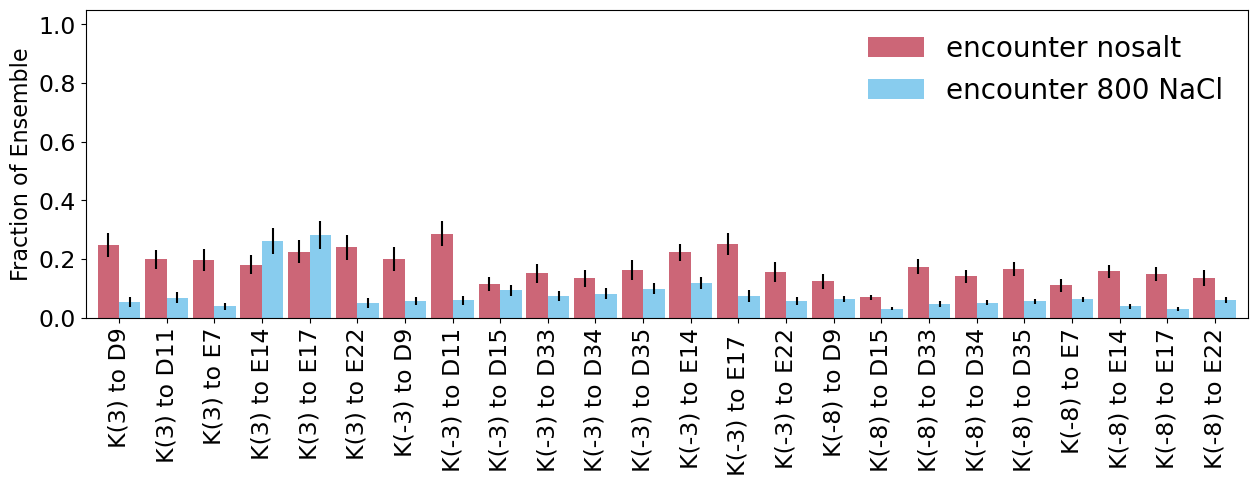

In [42]:
#making plot
plt.rcParams['figure.figsize'] = [15, 4]
ax1 = electrostat_frac_subset_rn.dropna(axis=0)[['encounter nosalt', 'encounter 800 NaCl']].plot.bar(fontsize = 17, width=0.9
                                                                                                     ,color=['#CC6677','#88CCEE'], 
 yerr = electrostat_frac_sem_subset_rn.dropna(axis=0)[['encounter nosalt', 'encounter 800 NaCl']])

ax1.set_ylim(bottom=0, top=1.05)
plt.ylabel('Fraction of Ensemble', size =16) # gives a name to the y-axis
plt.legend(fontsize = 20, frameon=False, loc="upper right")
#plt.savefig('electrostats_bound_encounter_long_ArkA12_with_errbars.png', dpi=2000)